# Selbstlernskript: PatchTST mit Hugging Face

**Bearbeitungszeit:** ca. 15 Minuten  

## Key Learnings

1. Warum zerlegt PatchTST Zeitreihen in **Patches**?
2. Was bedeutet **Channel Independence**?
3. Wie hängen `context_length`, `prediction_length`, `patch_length` und `patch_stride` zusammen?
4. Wie trainiert man PatchTST supervised mit HuggingFace?


## 0. Setup

Pakete installieren, falls noch nicht vorhanden:

```bash
pip install transformers torch pandas matplotlib
```


In [1]:
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import PatchTSTConfig, PatchTSTForPrediction

torch.manual_seed(42)

print("PyTorch:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

PyTorch: 2.12.1+cpu
Device: cpu


## 1. Daten laden

In [2]:
# Wenn df bereits existiert, wird es genutzt. Sonst wird weather.csv geladen.
try:
    df
    print("Bestehendes df wird verwendet.")
except NameError:
    df = pd.read_csv("data\weather.csv")
    print("weatherHistory.csv wurde geladen.")

weatherHistory.csv wurde geladen.


In [3]:
# TODO: Nutze geeignete Funktionen, um dir einen Überblick über die vorhandenen Signale des DataFrames zu machen
print(df.info())
print(df.describe())
print(df.head())
print("Shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                8760 non-null   int64  
 1   Formatted Date            8760 non-null   object 
 2   Summary                   8760 non-null   object 
 3   Precip Type               8386 non-null   object 
 4   Temperature (C)           8760 non-null   float64
 5   Apparent Temperature (C)  8760 non-null   float64
 6   Humidity                  8760 non-null   float64
 7   Wind Speed (km/h)         8760 non-null   float64
 8   Wind Bearing (degrees)    8760 non-null   float64
 9   Visibility (km)           8760 non-null   float64
 10  Loud Cover                8760 non-null   float64
 11  Pressure (millibars)      8760 non-null   float64
 12  Daily Summary             8760 non-null   object 
dtypes: float64(8), int64(1), object(4)
memory usage: 889.8+ KB
None

In [4]:
# TODO: Bestimme die Zeitspalte der Zeitserie:
time_col = "Formatted Date"

# TODO: Wähle nun die Features aus, die du vorhersagen möchtest:
target_cols = [
    "Temperature (C)",
    "Humidity",
    "Wind Speed (km/h)",
    "Wind Bearing (degrees)",
    "Visibility (km)",
]

In [5]:
# Vorverarbeitung

df = df[[time_col] + target_cols].dropna().copy() # Limitieren auf relevante Spalten und NaN-Werte entfernen
df[time_col] = pd.to_datetime(df[time_col], utc=True) # Zeitspalte ins DateTime-Format bringen
df = df.sort_values(time_col).reset_index(drop=True) # sortieren

df.head()

,Formatted Date,Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km)
0,2015-12-31 23:00:00+00:00,-6.361111,0.82,6.0858,121.0,15.8263
1,2016-01-01 00:00:00+00:00,-7.900000,0.89,3.2200,140.0,14.8764
2,2016-01-01 01:00:00+00:00,-8.522222,0.88,6.0536,138.0,15.7297
3,2016-01-01 02:00:00+00:00,-8.561111,0.88,6.4400,140.0,15.7297
4,2016-01-01 03:00:00+00:00,-8.577778,0.92,5.5867,137.0,14.0875


### Mini-Aufgabe 1

Visualisiere eine Variable. Was sehen Sie: Tageszyklus, Ausreißer, Trend?


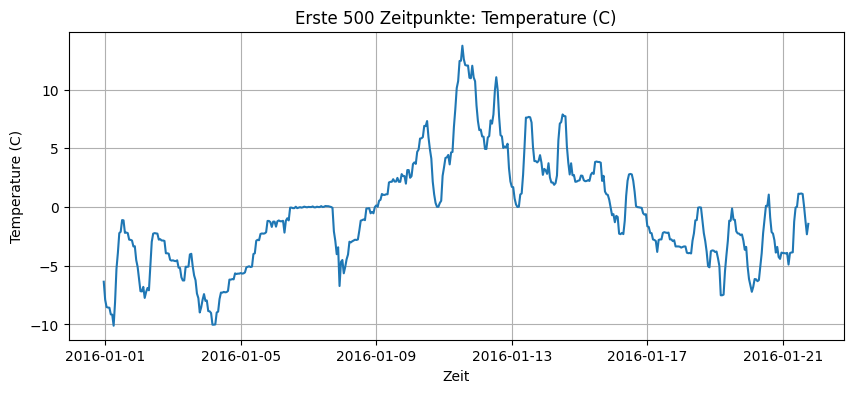

In [6]:
# TODO: Hier ist Platz für deinen Code

plot_col = "Temperature (C)"

plt.figure(figsize=(10, 4))
plt.plot(df[time_col].iloc[:500], df[plot_col].iloc[:500])
plt.title(f"Erste 500 Zeitpunkte: {plot_col}")
plt.xlabel("Zeit")
plt.ylabel(plot_col)
plt.grid(True)
plt.show()

## 2. Dataset-Klasse

Jedes Sample besteht aus:

```text
x = context_length vergangene Zeitschritte
y = prediction_length zukünftige Zeitschritte
```

Die Tensorform ist:

```text
x: [context_length, num_channels]
y: [prediction_length, num_channels]
```


In [7]:
class TimeSeriesDataset(Dataset):
    def __init__(self,df,time_col,target_cols,context_length,prediction_length,scaler=None,fit_scaler=False):
        df = df.copy()
        df[time_col] = pd.to_datetime(df[time_col], utc=True)
        df = df.sort_values(time_col).reset_index(drop=True)

        self.context_length = context_length
        self.prediction_length = prediction_length

        values = df[target_cols].values.astype("float32")

        if scaler is None:
            scaler = StandardScaler()

        if fit_scaler:
            scaler.fit(values)

        self.scaler = scaler

        values = self.scaler.transform(values)

        self.data = torch.tensor(values, dtype=torch.float32)

    def __len__(self):
        return len(self.data) - self.context_length - self.prediction_length + 1

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.context_length]
        y = self.data[
            idx + self.context_length :
            idx + self.context_length + self.prediction_length
        ]
        return x, y

## 3. Experimente definieren

Es sollen PatchTST-relevante Größen getestet werden:

- `context_length`: Wie viel Vergangenheit sieht das Modell?
- `prediction_length`: Wie weit wird vorhergesagt?
- `patch_length`: Wie viele Werte bilden ein Patch?
- `patch_stride`: Wie stark überlappen Patches?

Die Wetterdaten liegen stündlich vor:

- `168` = 7 Tage Vergangenheit
- `336` = 14 Tage Vergangenheit
- `24` = 24 Stunden Vorhersage
- `48` = 48 Stunden Vorhersage


In [8]:
# TODO: Wähle hier sinnvolle Ausprägungen, welche trainiert werden sollen:

# TODO: Länge des Rückblick- und Vorhersagefensters
context_lengths = [168, 336]
prediction_lengths = [24, 48]

# TODO: Patch und Stride
patch_length = 16
patch_stride = 8

# TODO: Anzahl der Eingabekanäle
num_channels = len(target_cols)

# TODO: Wähle einen sinnvollen Train/Test-Split
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

# Split
train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

# Größen der Datensätze ausgeben
print(len(train_df), len(val_df), len(test_df))

6132 1314 1314


### Mini-Aufgabe 2

Berechnen Sie gedanklich die Anzahl der Patches für `context_length=168`, `patch_length=16`, `patch_stride=8`:

\[
N = \left\lfloor\frac{L-P}{S}\right\rfloor + 1
\]


In [9]:
## TODO: Berechne hier die Anzahl der Patches
def num_patches(context_length, patch_length, patch_stride):
    return ((context_length - patch_length) // patch_stride) + 1

for cl in context_lengths:
    print(
        f"context_length={cl}: "
        f"{num_patches(cl, patch_length, patch_stride)} Patches"
    )

context_length=168: 20 Patches
context_length=336: 41 Patches


## 4. DataLoader und Modellconfigs erzeugen

In [10]:
batch_size = 32
dataloaders = {}
modelconfigs = {}

for context_len in context_lengths:
    for pred_len in prediction_lengths:
        train_dataset = TimeSeriesDataset(
            train_df,
            time_col,
            target_cols,
            context_len,
            pred_len,
            scaler=None,
            fit_scaler=True,
        )

        scaler = train_dataset.scaler

        val_dataset = TimeSeriesDataset(
            val_df,
            time_col,
            target_cols,
            context_len,
            pred_len,
            scaler=scaler,
            fit_scaler=False,
        )

        test_dataset = TimeSeriesDataset(
            test_df,
            time_col,
            target_cols,
            context_len,
            pred_len,
            scaler=scaler,
            fit_scaler=False,
        )

        dataloaders[(context_len, pred_len)] = {
            "train": DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True),
            "val": DataLoader(val_dataset, batch_size=batch_size, shuffle=False),
            "test": DataLoader(test_dataset, batch_size=batch_size, shuffle=False),
        }

        # TODO: Konfiguriere hier dein PatchTST-Modell 
        modelconfigs[(context_len, pred_len)] = PatchTSTConfig(
            num_input_channels=num_channels,
            context_length=context_len,
            prediction_length=pred_len,
            patch_length=patch_length,
            patch_stride=patch_stride,
            loss="mse",
            scaling=None,
        )

x, y = next(iter(dataloaders[(168, 24)]["train"]))
print("x shape:", x.shape)
print("y shape:", y.shape)
print("x mean:", x.mean().item())
print("x std:", x.std().item())

x shape: torch.Size([32, 168, 5])
y shape: torch.Size([32, 24, 5])
x mean: -0.02240673080086708
x std: 1.0133893489837646


## 5. Modelle trainieren


In [11]:
# TODO: Wähle die Anzahl der zu trainierenden Epochen
num_epochs = 3 

learning_curves = {}
models = {}

total = len(context_lengths) * len(prediction_lengths)
counter = 1

for context_len in context_lengths:
    for pred_len in prediction_lengths:
        print(f"\nModell {counter}/{total}: CL={context_len}, PL={pred_len}")
        counter += 1

        model = PatchTSTForPrediction(modelconfigs[(context_len, pred_len)])
        optimizer = AdamW(model.parameters(), lr=1e-4)

        train_loader = dataloaders[(context_len, pred_len)]["train"]
        val_loader = dataloaders[(context_len, pred_len)]["val"]

        train_losses = []
        val_losses = []

        for epoch in range(num_epochs):
            model.train()
            train_loss = 0.0

            for x_batch, y_batch in train_loader:
                optimizer.zero_grad()

                outputs = model(
                    past_values=x_batch,
                    future_values=y_batch
                )

                loss = outputs.loss
                loss.backward()
                optimizer.step()

                train_loss += loss.item()

            train_loss /= len(train_loader)
            train_losses.append(train_loss)

            model.eval()
            val_loss = 0.0

            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    outputs = model(
                        past_values=x_batch,
                        future_values=y_batch
                    )
                    val_loss += outputs.loss.item()

            val_loss /= len(val_loader)
            val_losses.append(val_loss)

            print(
                f"Epoch {epoch+1}/{num_epochs} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_loss:.4f}"
            )

        learning_curves[(context_len, pred_len)] = {
            "train_loss": train_losses,
            "val_loss": val_losses,
        }
        models[(context_len, pred_len)] = model

        # Modellparameter und Lernkurven abspeichern
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "config": model.config,
            },
            f"trained_models_loesung/model_context_{context_len}_pred_{pred_len}.pt"
        )

# Lernkurven aller Trainingsläufe abspeichern
torch.save(learning_curves, "trained_models_loesung\learning_curves.pt")


Modell 1/4: CL=168, PL=24
Epoch 1/5 | Train Loss: 0.7640 | Val Loss: 0.6251
Epoch 2/5 | Train Loss: 0.6668 | Val Loss: 0.5694
Epoch 3/5 | Train Loss: 0.5983 | Val Loss: 0.5446
Epoch 4/5 | Train Loss: 0.5778 | Val Loss: 0.5288
Epoch 5/5 | Train Loss: 0.5646 | Val Loss: 0.5422

Modell 2/4: CL=168, PL=48
Epoch 1/5 | Train Loss: 0.7997 | Val Loss: 0.6960
Epoch 2/5 | Train Loss: 0.7378 | Val Loss: 0.7091
Epoch 3/5 | Train Loss: 0.6714 | Val Loss: 0.6267
Epoch 4/5 | Train Loss: 0.6306 | Val Loss: 0.6178
Epoch 5/5 | Train Loss: 0.6145 | Val Loss: 0.6188

Modell 3/4: CL=336, PL=24
Epoch 1/5 | Train Loss: 0.7804 | Val Loss: 0.6240
Epoch 2/5 | Train Loss: 0.6738 | Val Loss: 0.5541
Epoch 3/5 | Train Loss: 0.5950 | Val Loss: 0.5330
Epoch 4/5 | Train Loss: 0.5712 | Val Loss: 0.4980
Epoch 5/5 | Train Loss: 0.5610 | Val Loss: 0.4877

Modell 4/4: CL=336, PL=48
Epoch 1/5 | Train Loss: 0.8095 | Val Loss: 0.6942
Epoch 2/5 | Train Loss: 0.7561 | Val Loss: 0.6655
Epoch 3/5 | Train Loss: 0.7263 | Val Loss:

## 6. Learning Curves vergleichen

`num_epochs=1` --> nur 1 Punkt sichtbar. Für echte Kurven `num_epochs>1`


In [12]:
def describe_structure(obj, indent=0):
    prefix = "    " * indent

    if isinstance(obj, dict):
        print(f"{prefix}dict ({len(obj)} keys)")
        for k, v in obj.items():
            print(f"{prefix}├── {k}")
            describe_structure(v, indent + 1)

    elif isinstance(obj, list):
        print(f"{prefix}list (len={len(obj)})")
        if obj:
            describe_structure(obj[0], indent + 1)

    else:
        print(f"{prefix}{type(obj).__name__}")

dict (4 keys)
├── (168, 24)
    dict (2 keys)
    ├── train_loss
        list (len=5)
            float
    ├── val_loss
        list (len=5)
            float
├── (168, 48)
    dict (2 keys)
    ├── train_loss
        list (len=5)
            float
    ├── val_loss
        list (len=5)
            float
├── (336, 24)
    dict (2 keys)
    ├── train_loss
        list (len=5)
            float
    ├── val_loss
        list (len=5)
            float
├── (336, 48)
    dict (2 keys)
    ├── train_loss
        list (len=5)
            float
    ├── val_loss
        list (len=5)
            float
{(168, 24): {'train_loss': [0.763998701121356, 0.6668393209173873, 0.5982751377531, 0.577759530898687, 0.5645746148921348], 'val_loss': [0.6250667683780193, 0.569377101957798, 0.5445999726653099, 0.5288477804925706, 0.5421993502726158]}, (168, 48): {'train_loss': [0.7997486850489741, 0.7378300353884697, 0.6713745156707971, 0.6306146781729616, 0.6145406404267186], 'val_loss': [0.6959723740816116, 0.7

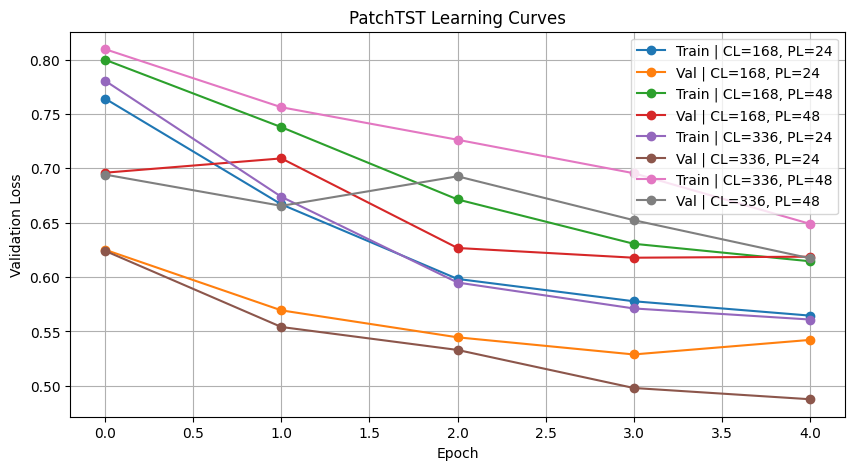

In [13]:
# Lernkurven laden
learning_curves = torch.load("trained_models_loesung\learning_curves.pt")
# Strucktur des Dictionarys ausgeben:
describe_structure(learning_curves)

# TODO: Visualisiere deine Lernkurven: 
print(learning_curves)
plt.figure(figsize=(10, 5))

for (context_len, pred_len), curves in learning_curves.items():
    plt.plot(
        curves["train_loss"],
        marker="o",
        label=f"Train | CL={context_len}, PL={pred_len}"
    )
    plt.plot(
        curves["val_loss"],
        marker="o",
        label=f"Val | CL={context_len}, PL={pred_len}"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("PatchTST Learning Curves")
plt.legend()
plt.grid(True)
plt.show()

## 7. Vorhersagequalität auf Testdatensatz vergleichen

In [14]:
import torch.nn.functional as F

# Evaluierung auf Test-Datensatz

test_mse = {}
test_mse_channels = {}

for context_len in context_lengths:
    for pred_len in prediction_lengths:

        checkpoint = torch.load(
            f"trained_models_loesung/model_context_{context_len}_pred_{pred_len}.pt",
            map_location="cpu",
            weights_only=False
        )

        model = PatchTSTForPrediction(checkpoint["config"])
        model.load_state_dict(checkpoint["model_state_dict"])
        model.eval()

        test_loader = dataloaders[(context_len, pred_len)]["test"]

        mse = 0.0

        # MSE pro Kanal sammeln
        channel_mse = torch.zeros(num_channels)

        with torch.no_grad():
            for x_batch, y_batch in test_loader:

                outputs = model(
                    past_values=x_batch,
                    future_values=y_batch
                )

                pred = outputs.prediction_outputs

                # Gesamt-MSE
                mse += outputs.loss.item()

                # MSE je Kanal
                for c in range(num_channels):
                    channel_mse[c] += F.mse_loss(
                        pred[:, :, c],
                        y_batch[:, :, c]
                    ).item()

        # Mittelwert über alle Test-Batches
        mse /= len(test_loader)
        channel_mse /= len(test_loader)

        test_mse[(context_len, pred_len)] = mse

        test_mse_channels[(context_len, pred_len)] = {
            target_cols[c]: channel_mse[c].item()
            for c in range(num_channels)
        }

        print(f"\nContext={context_len}, Prediction={pred_len}")
        print(f"Gesamt-MSE: {mse:.4f}")

        print("MSE je Kanal:")
        for name, value in test_mse_channels[(context_len, pred_len)].items():
            print(f"  {name:<25}: {value:.4f}")


Context=168, Prediction=24
Gesamt-MSE: 0.0590
MSE je Kanal:
  Temperature (C)          : 0.0587
  Humidity                 : 0.0127
  Wind Speed (km/h)        : 0.0232
  Wind Bearing (degrees)   : 0.0175
  Visibility (km)          : 0.1828

Context=168, Prediction=48
Gesamt-MSE: 0.0566
MSE je Kanal:
  Temperature (C)          : 0.0677
  Humidity                 : 0.0375
  Wind Speed (km/h)        : 0.0255
  Wind Bearing (degrees)   : 0.0221
  Visibility (km)          : 0.1300

Context=336, Prediction=24
Gesamt-MSE: 0.0518
MSE je Kanal:
  Temperature (C)          : 0.0092
  Humidity                 : 0.0209
  Wind Speed (km/h)        : 0.0463
  Wind Bearing (degrees)   : 0.0397
  Visibility (km)          : 0.1430

Context=336, Prediction=48
Gesamt-MSE: 0.0963
MSE je Kanal:
  Temperature (C)          : 0.0366
  Humidity                 : 0.0309
  Wind Speed (km/h)        : 0.0664
  Wind Bearing (degrees)   : 0.0354
  Visibility (km)          : 0.3123


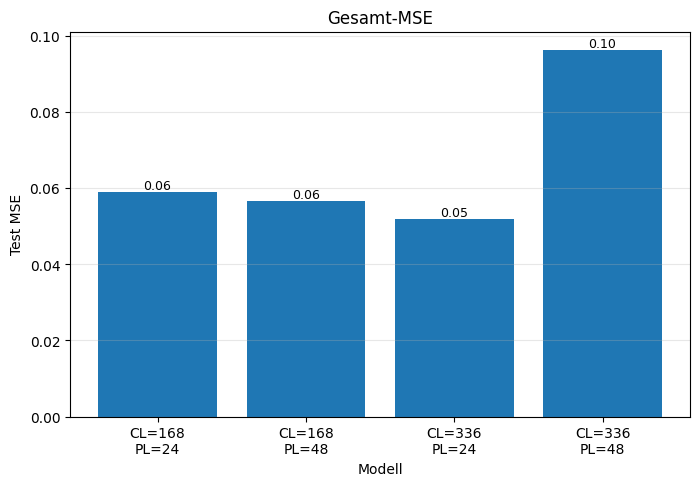

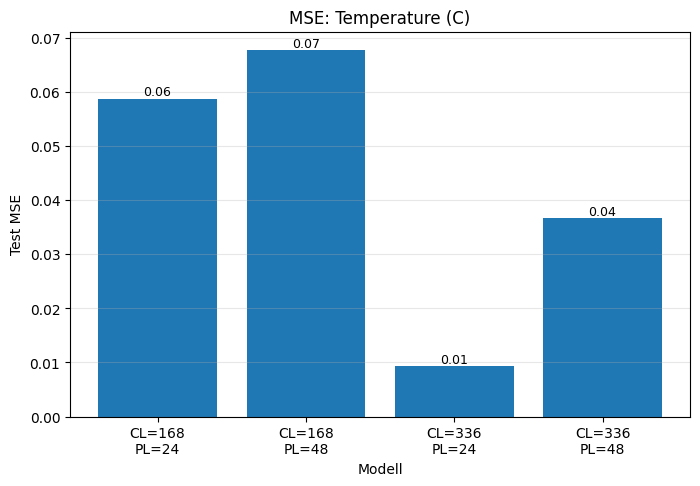

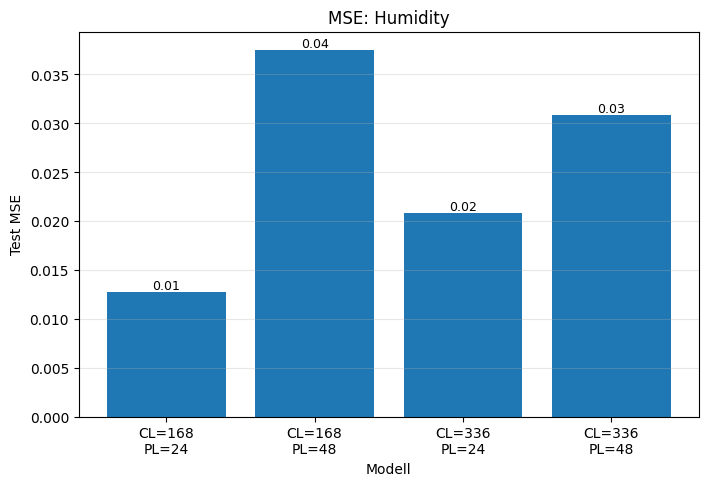

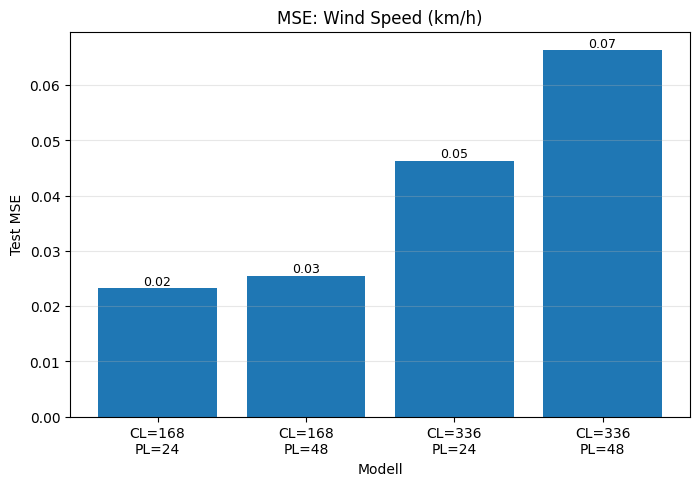

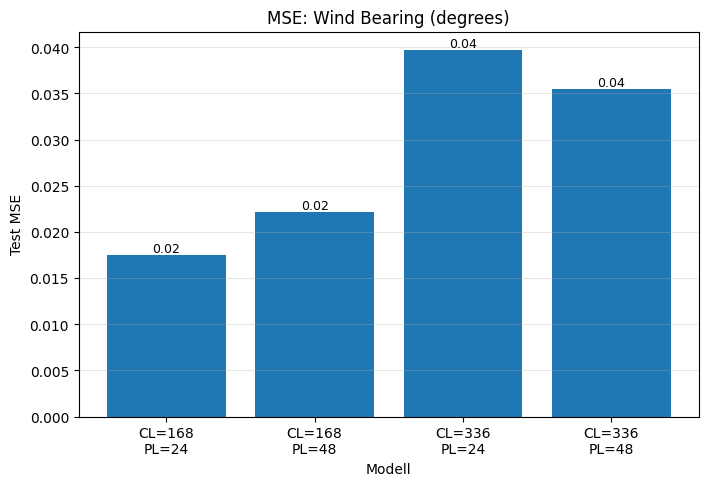

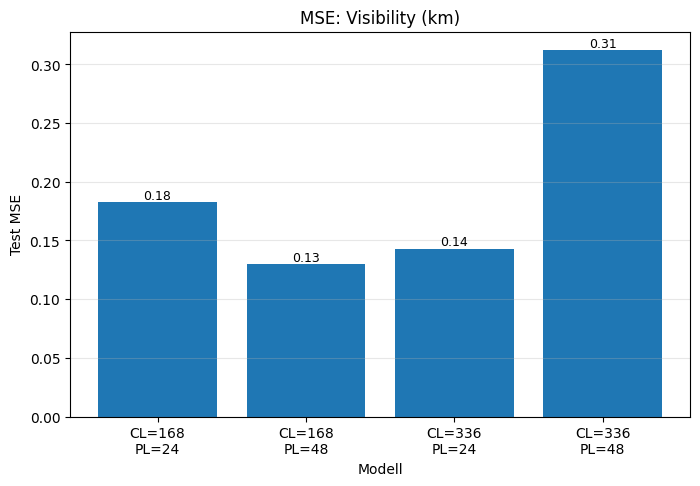

In [15]:
# Gesamt-MSE
labels = [
    f"CL={cl}\nPL={pl}"
    for cl, pl in test_mse.keys()
]

values = list(test_mse.values())

plt.figure(figsize=(8, 5))

bars = plt.bar(labels, values)

plt.ylabel("Test MSE")
plt.xlabel("Modell")
plt.title("Gesamt-MSE")
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.show()


# MSE je Kanal
for channel in target_cols:

    values = [
        test_mse_channels[(cl, pl)][channel]
        for cl, pl in test_mse.keys()
    ]

    plt.figure(figsize=(8, 5))

    bars = plt.bar(labels, values)

    plt.ylabel("Test MSE")
    plt.xlabel("Modell")
    plt.title(f"MSE: {channel}")
    plt.grid(axis="y", alpha=0.3)

    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.show()

### Mini-Aufgabe 3

Interpretieren, sofern ausreichend viele Epochen trainiert wurden:

1. Wird die Vorhersage schwieriger, wenn `prediction_length` größer wird?
2. Hilft eine längere `context_length`?
3. Siehst du Anzeichen für Underfitting oder Overfitting?

## 8. Eine Vorhersage visualisieren

Wählen Sie die beste oder interessanteste Konfiguration aus.


x shape: torch.Size([1, 336, 5])
y shape: torch.Size([1, 24, 5])
pred shape: torch.Size([1, 24, 5])


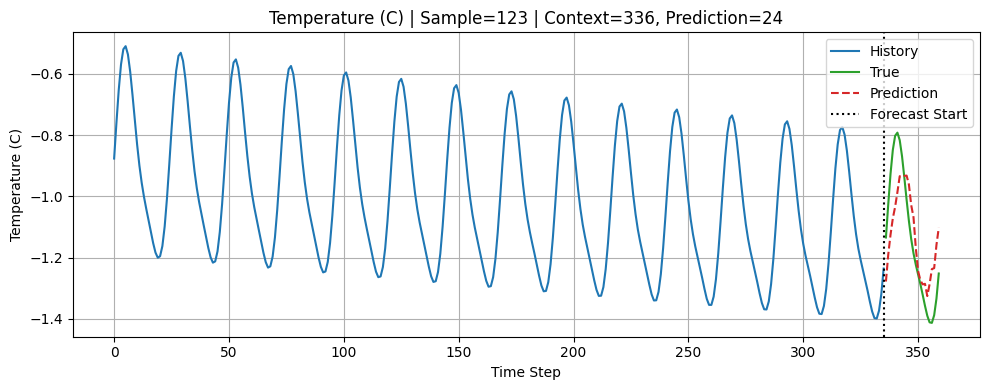

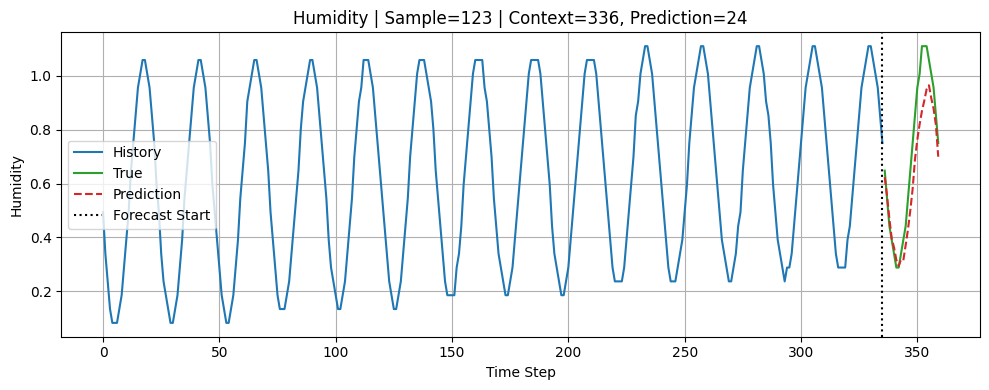

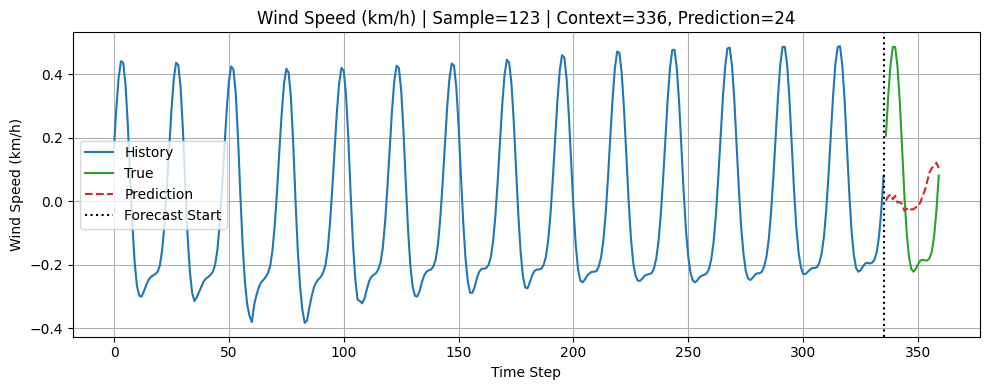

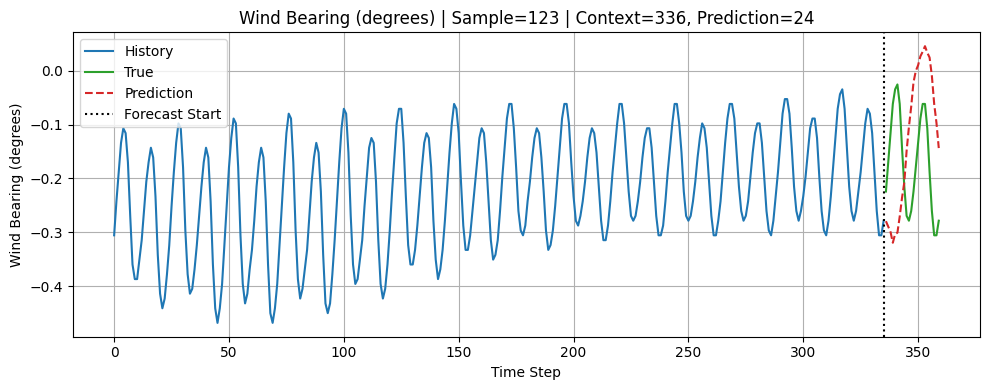

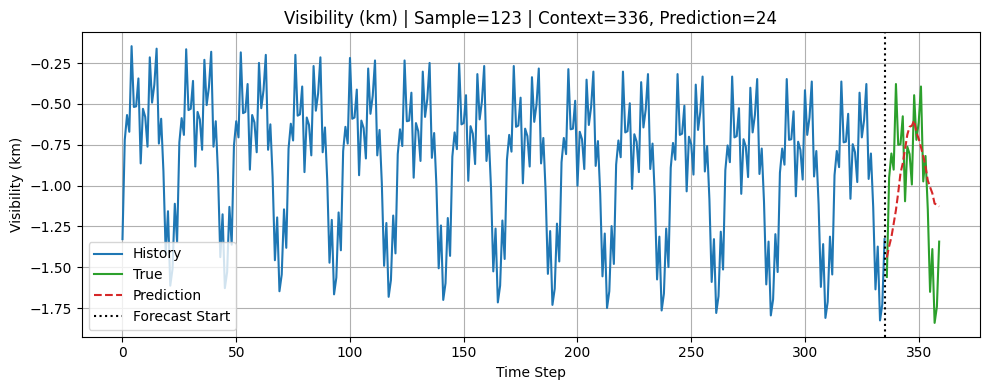

In [17]:
selected_context = 336
selected_pred = 24
sample_idx = 123  # <-- beliebiges Test-Sample

model = models[(selected_context, selected_pred)]

test_dataset = dataloaders[(selected_context, selected_pred)]["test"].dataset

x, y = test_dataset[sample_idx]

# Batch-Dimension hinzufügen
x = x.unsqueeze(0)
y = y.unsqueeze(0)

model.eval()
with torch.no_grad():
    outputs = model(past_values=x)

pred = outputs.prediction_outputs

# Prüfen der Dimensionen
print("x shape:", x.shape)
print("y shape:", y.shape)
print("pred shape:", pred.shape)

for channel_idx, channel_name in enumerate(target_cols):

    plt.figure(figsize=(10, 4))

    # Vergangenheit
    plt.plot(
        range(selected_context),
        x[0, :, channel_idx].numpy(),
        label="History",
        color="tab:blue"
    )

    # Tatsächliche Zukunft
    plt.plot(
        range(selected_context, selected_context + selected_pred),
        y[0, :, channel_idx].numpy(),
        label="True",
        color="tab:green"
    )

    # Vorhersage
    plt.plot(
        range(selected_context, selected_context + selected_pred),
        pred[0, :, channel_idx].detach().numpy(),
        label="Prediction",
        color="tab:red",
        linestyle="--"
    )

    plt.axvline(
        selected_context - 1,
        color="black",
        linestyle=":",
        label="Forecast Start"
    )

    plt.title(
        f"{channel_name} | Sample={sample_idx} | "
        f"Context={selected_context}, Prediction={selected_pred}"
    )

    plt.xlabel("Time Step")
    plt.ylabel(channel_name)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 8. Abschlussreflexion

Beantworten Sie kurz:

1. Was ist der Unterschied zwischen `context_length` und `patch_length`?
2. Warum reduziert Patching den Rechenaufwand?
3. Warum ist Channel Independence bei vielen Sensor- oder Wetterdaten plausibel?
4. Bei welchen Daten wäre Channel Independence problematisch?
5. Welche Konfiguration hat am besten funktioniert?

## Merksatz

PatchTST unterscheidet sich vor allem dadurch, dass es **Zeitreihen in Patches tokenisiert** und **jeden Channel zunächst unabhängig verarbeitet**. Dadurch kann das Modell lange historische Fenster effizienter nutzen.


1. Was ist der Unterschied zwischen context_length und patch_length?
context_length gibt die Länge des gesamten Eingabefensters an, patch_length die Anzahl der Zeitpunkte, die zu einem Patch zusammengefasst werden.
2. Warum reduziert Patching den Rechenaufwand?
Mehrere Zeitpunkte werden zu einem Token zusammengefasst. Dadurch verarbeitet der Transformer weniger Tokens, wodurch insbesondere die Self-Attention effizienter wird.
3. Warum ist Channel Independence bei vielen Sensor- oder Wetterdaten plausibel?
Viele Variablen besitzen eine eigene zeitliche Dynamik und können unabhängig modelliert werden. Der gleiche Transformer lernt dabei allgemeine zeitliche Muster für alle Channels.
4. Bei welchen Daten wäre Channel Independence problematisch?
Bei stark gekoppelten Systemen, in denen sich Variablen gegenseitig beeinflussen, z. B. in chemischen Prozessen, Motorsteuerungen oder physikalischen Regelkreisen.
5. Welche Konfiguration hat am besten funktioniert?
Individuelle Antwort